In [47]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import seaborn as sns

# Explore Type & Availability of Data

In [2]:
df = pd.read_csv(
    'data/Property_Transaction_Data.csv', 
    encoding='utf-16',
    sep='\t',
    on_bad_lines='skip'
)
df.head()

,Property Type,District,Mukim,Scheme Name/Area,Road Name,"Month, Year of Transaction Date",Tenure,Land/Parcel Area,Unit,Main Floor Area,Unit,Unit Level,Transaction Price,Unnamed: 13
0,1 - 1 1/2 Storey Semi-Detached,Gombak,Bandar Batu Arang,KOTA PUTERI BANDAR BARU BT ARANG,JALAN KOTA PUTERI 5/8A,August 2021,Leasehold,228.00,sq.m,74,sq.m,,"RM370,000.00",NaN
1,1 - 1 1/2 Storey Semi-Detached,Gombak,Bandar Batu Arang,KOTA PUTERI BANDAR BARU BT ARANG,JALAN KOTA PUTERI 5/8B,May 2021,Leasehold,394.00,sq.m,74,sq.m,,"RM405,000.00",NaN
2,1 - 1 1/2 Storey Semi-Detached,Gombak,Bandar Batu Arang,KOTA PUTERI BANDAR BARU BT ARANG,JALAN KOTA PUTERI 5/9A,July 2021,Leasehold,345.00,sq.m,94,sq.m,,"RM380,000.00",NaN
3,1 - 1 1/2 Storey Semi-Detached,Gombak,Bandar Gombak Setia,GOMBAK SETIA,JALAN IBUKOTA KIRI,February 2024,Leasehold,623.00,sq.m,157,sq.m,,"RM750,000.00",NaN
4,1 - 1 1/2 Storey Semi-Detached,Gombak,Bandar Selayang,TAMAN SELAYANG MUTIARA,JALAN MUTIARA 3/8A,October 2023,Leasehold,201.00,sq.m,74,sq.m,,"RM315,000.00",NaN


## First Check

In [3]:
pd.set_option('display.max_columns', None)
temp = df.groupby(['District']).size()

temp.sort_values(ascending=False)

District
Petaling          33437
Kuala Lumpur      25978
Hulu Langat       22723
Klang             18450
Gombak            12260
Sepang             7133
Kuala Langat       5760
Hulu Selangor      5373
Kuala Selangor     4935
Sabak Bernam        764
dtype: int64

In [4]:
df[df['District']=='Petaling']['Mukim'].unique()

<StringArray>
[     'Bandar Petaling Jaya',          'Bandar Shah Alam',
        'Bandar Subang Jaya',                'Bukit Raja',
             'Pekan Serdang',                  'Petaling',
              'Sungai Buluh', 'Bdr Petaling Jaya Selatan',
         'Bdr Sri Damansara',                'Bdr Sunway',
                 'Damansara',        'Pekan Baru Sg Besi',
       'Pekan Baru Sg Buluh',         'Pekan Baru Subang',
           'Pekan Batu Tiga',               'Pekan Hicom',
            'Pekan Kayu Ara',             'Pekan Kinrara',
        'Pekan Puchong Jaya',     'Pekan Puchong Perdana',
         'Pekan Subang Jaya',             'Bdr Damansara',
             'Bdr Glenmarie',               'Bdr Saujana',
            'Pekan Chempaka',        'Pekan Desa Puchong',
              'Pekan Penaga',         'Pekan Sg Penchala',
              'Pekan Subang',          'Pekan Baru Hicom',
     'Pekan Country Heights',        'Pekan Sungai Buloh']
Length: 32, dtype: str

In [26]:
df_kl = df[df['District']=='Kuala Lumpur']
print(f"Total transactions before filter: {len(df)}")
print(f"Total transactions in Kuala Lumpur: {len(df_kl)}")

Total transactions before filter: 136813
Total transactions in Kuala Lumpur: 25978


In [27]:
# investigate the date
np.sort(df_kl['Month, Year of Transaction Date'].unique())

# maximum: Dec 2025
# minimum: Jan 2021

array(['April 2021', 'April 2022', 'April 2023', 'April 2024',
       'April 2025', 'August 2021', 'August 2022', 'August 2023',
       'August 2024', 'August 2025', 'December 2021', 'December 2022',
       'December 2023', 'December 2024', 'December 2025', 'February 2021',
       'February 2022', 'February 2023', 'February 2024', 'February 2025',
       'January 2021', 'January 2022', 'January 2023', 'January 2024',
       'January 2025', 'July 2021', 'July 2022', 'July 2023', 'July 2024',
       'July 2025', 'June 2021', 'June 2022', 'June 2023', 'June 2024',
       'June 2025', 'March 2021', 'March 2022', 'March 2023',
       'March 2024', 'March 2025', 'May 2021', 'May 2022', 'May 2023',
       'May 2024', 'May 2025', 'November 2021', 'November 2022',
       'November 2023', 'November 2024', 'November 2025', 'October 2021',
       'October 2022', 'October 2023', 'October 2024', 'October 2025',
       'September 2021', 'September 2022', 'September 2023',
       'September 2024', 'Se

In [28]:
pd.set_option('display.max_rows', 10)

In [29]:
df_kl[df_kl['Scheme Name/Area']=='NIDOZ RESIDENCES @ DESA PETALING']

,Property Type,District,Mukim,Scheme Name/Area,Road Name,"Month, Year of Transaction Date",Tenure,Land/Parcel Area,Unit,Main Floor Area,Unit,Unit Level,Transaction Price,Unnamed: 13
91155,Condominium/Apartment,Kuala Lumpur,Mukim Petaling,NIDOZ RESIDENCES @ DESA PETALING,,January 2021,Leasehold,113.00,sq.m,-,-,27,"RM720,000.00",NaN
91156,Condominium/Apartment,Kuala Lumpur,Mukim Petaling,NIDOZ RESIDENCES @ DESA PETALING,,March 2021,Leasehold,121.00,sq.m,-,-,38,"RM750,000.00",NaN
91157,Condominium/Apartment,Kuala Lumpur,Mukim Petaling,NIDOZ RESIDENCES @ DESA PETALING,,March 2021,Leasehold,130.00,sq.m,-,-,27,"RM850,000.00",NaN
91158,Condominium/Apartment,Kuala Lumpur,Mukim Petaling,NIDOZ RESIDENCES @ DESA PETALING,,March 2021,Leasehold,130.00,sq.m,-,-,34,"RM870,000.00",NaN
91159,Condominium/Apartment,Kuala Lumpur,Mukim Petaling,NIDOZ RESIDENCES @ DESA PETALING,,May 2021,Leasehold,113.00,sq.m,-,-,18,"RM660,000.00",NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
91209,Condominium/Apartment,Kuala Lumpur,Mukim Petaling,NIDOZ RESIDENCES @ DESA PETALING,,April 2024,Leasehold,130.00,sq.m,-,-,21,"RM760,000.00",NaN
91210,Condominium/Apartment,Kuala Lumpur,Mukim Petaling,NIDOZ RESIDENCES @ DESA PETALING,,May 2024,Leasehold,113.00,sq.m,-,-,16,"RM680,000.00",NaN
91211,Condominium/Apartment,Kuala Lumpur,Mukim Petaling,NIDOZ RESIDENCES @ DESA PETALING,,May 2024,Leasehold,113.00,sq.m,-,-,17,"RM650,000.00",NaN
91212,Condominium/Apartment,Kuala Lumpur,Mukim Petaling,NIDOZ RESIDENCES @ DESA PETALING,,September 2024,Leasehold,113.00,sq.m,-,-,34,"RM680,000.00",NaN


## Quick Cleaning

In [30]:
remap_col = {
    'Property Type': 'property_type',
    'District': 'district',
    'Mukim': 'mukim',
    'Scheme Name/Area': 'scheme_name',
    'Road Name': 'road_name',
    'Month, Year of Transaction Date': 'txn_mth_id',
    'Tenure': 'tenure',
    'Land/Parcel Area': 'land_area_sqm',
    'Main Floor Area': 'main_floor_area',
    'Unit Level': 'unit_level',
    'Transaction Price  ': 'txn_price_rm'
}
df_kl.rename(columns=remap_col, inplace=True)

In [31]:
# drop useless columns
drop_cols = ['Unit        ', 'Unnamed: 13', 'Unit']
df_kl.drop(columns=drop_cols, inplace=True)

In [36]:
numeric_cols = ['land_area_sqm', 'main_floor_area', 'unit_level', 'txn_price_rm']
# massage txn price in rm
df_kl['txn_price_rm'] = df_kl['txn_price_rm'].replace('[RM,]', '', regex=True).astype(float)
df_kl['land_area_sqm'] = df_kl['land_area_sqm'].replace('[,]', '', regex=True).astype(float)
df_kl['main_floor_area'] = df_kl['main_floor_area'].replace('[,-]', '', regex=True)

for col in numeric_cols:
    df_kl[col] = pd.to_numeric(df_kl[col], errors='coerce')

In [44]:
df_kl['txn_mth_id'] = pd.to_datetime(df_kl['txn_mth_id'], format='%B %Y').dt.strftime('%Y-%m')

In [78]:
df_kl['land_area_sqft'] = df_kl['land_area_sqm'] * 10.76391
df_kl['main_floor_area_sqft'] = df_kl['main_floor_area'] * 10.76391

df_kl['txn_price_per_sqft'] = df_kl['txn_price_rm'] / df_kl['land_area_sqft']

## Trending - Scheme/ Property Type

In [56]:
df_kl.sample(10)

,property_type,district,mukim,scheme_name,road_name,txn_mth_id,tenure,land_area_sqm,main_floor_area,unit_level,txn_price_rm
94466,Condominium/Apartment,Kuala Lumpur,Mukim Setapak,SENTUL POINT SUITE APARTMENTS,,2022-05,Freehold,67.00,NaN,44.0,352000.0
47856,2 - 2 1/2 Storey Terraced,Kuala Lumpur,Mukim Kuala Lumpur,DESA SRI HARTAMAS,JALAN 45/70A,2024-05,Freehold,153.00,155.0,NaN,1835000.0
84971,Condominium/Apartment,Kuala Lumpur,Mukim Batu,RESIDENSI HERZ,,2022-05,Leasehold,99.68,NaN,35.0,493000.0
93859,Condominium/Apartment,Kuala Lumpur,Mukim Setapak,PRIMA SETAPAK II,,2024-09,Freehold,133.00,NaN,20.0,600000.0
126385,Low-Cost Flat,Kuala Lumpur,Mukim Petaling,BANDAR TASIK SELATAN,,2023-05,Leasehold,61.00,NaN,7.0,168000.0
48646,2 - 2 1/2 Storey Terraced,Kuala Lumpur,Mukim Petaling,BANDAR BARU SRI PETALING,JLN SERI PETALING 3,2022-12,Leasehold,163.00,125.0,NaN,800000.0
82696,Condominium/Apartment,Kuala Lumpur,Mukim Batu,11 MONT KIARA,,2024-09,Freehold,307.00,NaN,28.0,2900000.0
47509,2 - 2 1/2 Storey Terraced,Kuala Lumpur,Mukim Batu,TMN SRI SINAR,JLN 34C/38A,2023-03,Freehold,56.00,95.0,NaN,450000.0
83904,Condominium/Apartment,Kuala Lumpur,Mukim Batu,MIZUMI RESIDENCES,,2022-10,Leasehold,87.00,NaN,18.0,490000.0
19613,2 - 2 1/2 Storey Semi-Detached,Kuala Lumpur,Mukim Kuala Lumpur,RESIDENSI PUNCAK TTDI (TTDI 16),LORONG CAHAYA 1(RES PUNCAK TTDI),2024-02,Freehold,279.00,389.0,NaN,2960000.0


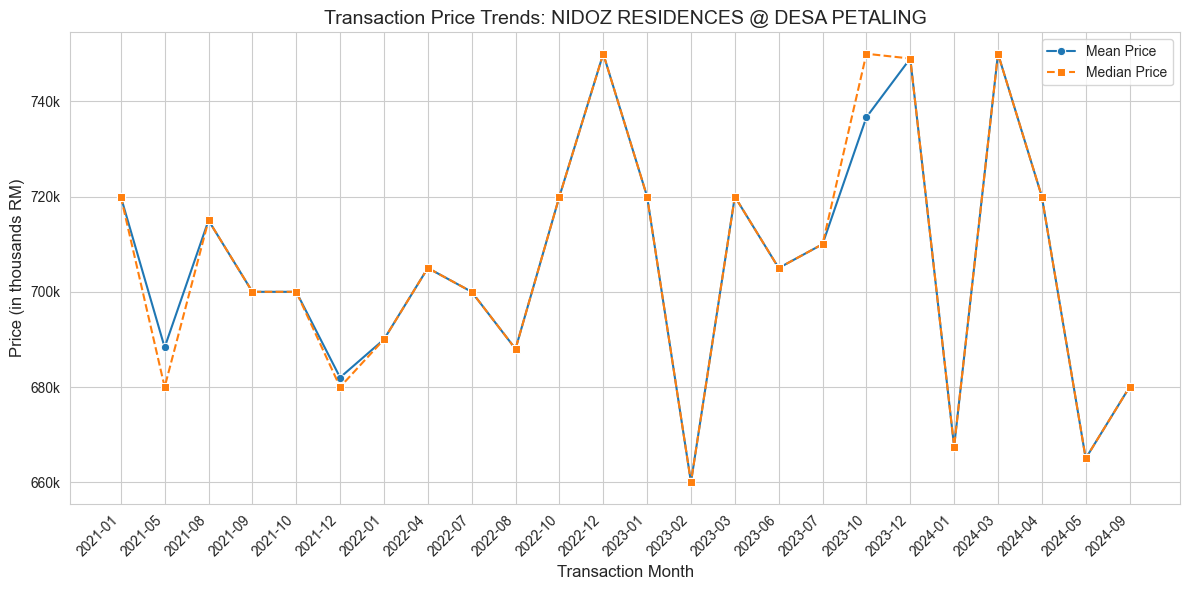

In [57]:
import importlib
from utils import plot_scheme_trend
importlib.reload(plot_scheme_trend)

from utils.plot_scheme_trend import plot_scheme_trends

plot_scheme_trends(df_kl, 'NIDOZ RESIDENCES @ DESA PETALING', land_area_sqm=113)

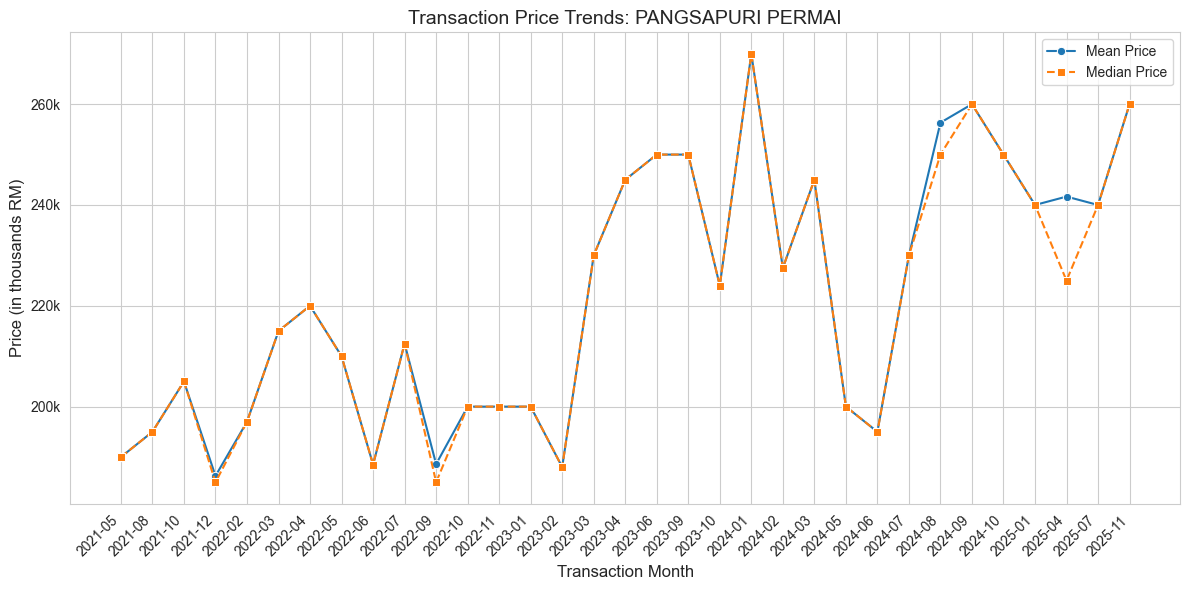

In [55]:
plot_scheme_trends(df_kl, 'PANGSAPURI PERMAI')

In [60]:
# trending of kl prices
cond = [
    (df_kl['property_type'].str.contains('Semi-Detached', case=False, na=False)),
    (df_kl['property_type'].str.contains('Terrace', case=False, na=False))
]

df_kl['property_type_grouped'] = np.select(cond, ['Semi-D', 'Terrace'], default=df_kl['property_type'])

In [61]:
df_kl['property_type_grouped'].value_counts()

property_type_grouped
Condominium/Apartment    15053
Terrace                   4581
Low-Cost Flat             2423
Flat                      2001
Detached                   706
Semi-D                     587
Town House                 341
Cluster House              165
Low-Cost House             121
Name: count, dtype: int64

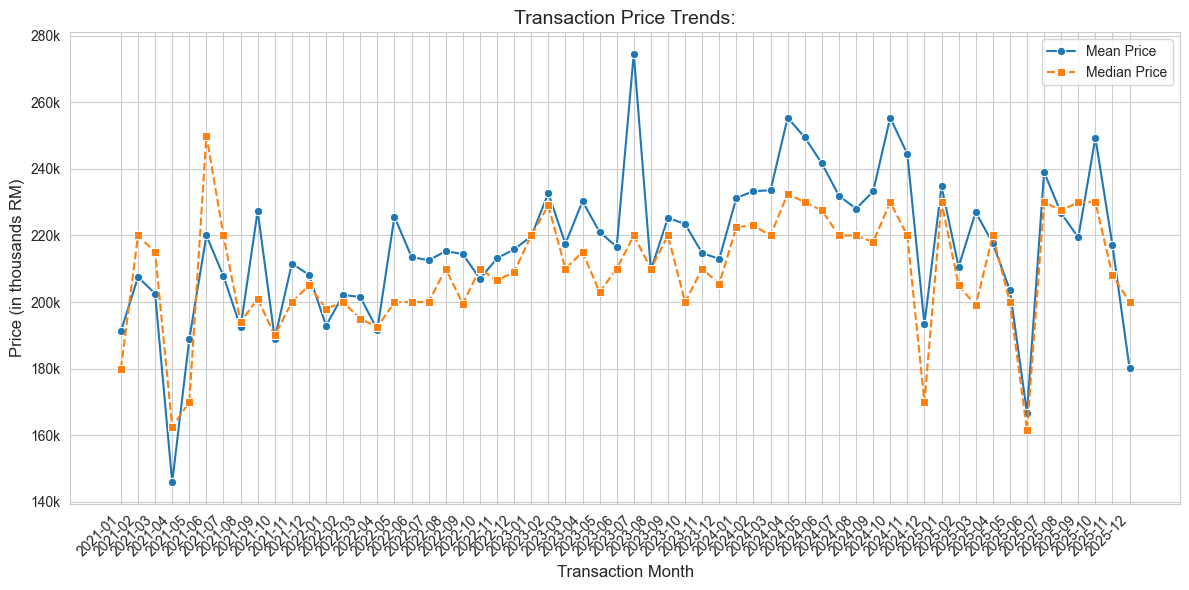

In [64]:
# mask = (df_kl['property_type_grouped'].isin(['Condominium/Apartment']))
mask = (df_kl['property_type_grouped'].isin(['Low-Cost Flat', 'Flat']))

df_filtered = df_kl[mask].groupby(['txn_mth_id']).agg(
    txn_price_mean=('txn_price_rm', 'mean'),
    txn_price_median=('txn_price_rm', 'median')
).reset_index().sort_values('txn_mth_id')

plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

# 3. Plotting
sns.lineplot(data=df_filtered, x='txn_mth_id', y='txn_price_mean', marker='o', label='Mean Price')
sns.lineplot(data=df_filtered, x='txn_mth_id', y='txn_price_median', marker='s', linestyle='--', label='Median Price')

# 4. Formatter for Y-axis (thousands)
def thousands_formatter(x, pos):
    return f'{x/1000:,.0f}k'

plt.gca().yaxis.set_major_formatter(FuncFormatter(thousands_formatter))

# 5. Formatting
plt.xticks(rotation=45, ha='right')
plt.title(f'Transaction Price Trends:', fontsize=14)
plt.xlabel('Transaction Month', fontsize=12)
plt.ylabel('Price (in thousands RM)', fontsize=12)
plt.legend()
plt.tight_layout()

plt.show()

In [65]:
df_kl.columns

Index(['property_type', 'district', 'mukim', 'scheme_name', 'road_name',
       'txn_mth_id', 'tenure', 'land_area_sqm', 'main_floor_area',
       'unit_level', 'txn_price_rm', 'property_type_grouped'],
      dtype='str')

In [79]:
# save the cleaned data for dashboard use
df_kl.to_csv('data/kl_property_txn_cleaned.csv', index=False)

In [94]:
df_kl.reset_index(drop=True).to_csv('data/kl_property_txn_sample.csv')

In [1]:
import os
from dotenv import load_dotenv
from supabase import create_client, Client

In [3]:
load_dotenv()

supabase: Client = create_client(
    os.environ.get("SUPABASE_URL"),
    os.environ.get("SUPABASE_KEY")
)

response = supabase.schema('main').table('property_master_kl').select("mukim").limit(10).execute()
# response = supabase.table('test').select('*').execute()
print(response)
# Client.close(supabase)

data=[] count=None
